In [1]:
import numpy as np 
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid

import sys
from importlib import reload

%matplotlib inline

import pyPamtra
help(pyPamtra)


Help on package pyPamtra:

NAME
    pyPamtra - # -*- coding: utf-8 -*-

PACKAGE CONTENTS
    core
    descriptorFile
    fortranNamelist (package)
    importer
    libWrapper
    meteoSI
    pamtra
    plot
    pyPamtraLib
    tools

FILE
    /work/users/exp/roversi/anaconda3/envs/pamtra/lib/python3.13/site-packages/pyPamtra/__init__.py




## INSERIRE I DATI DEI DISDROMETRI (bins, edges)

In [2]:
data = xr.load_dataset('/home/roversi/work/pamtra_db/data/haloac3_dataset_for_pamtra.nc')
data

<xarray.Dataset> Size: 3MB
Dimensions:        (time: 114, height: 1400, bin_mid: 95)
Coordinates:
  * time           (time) datetime64[ns] 912B 2022-04-01T11:25:00 ... 2022-04...
  * height         (height) float32 6kB -1e+03 -995.0 ... 5.99e+03 5.995e+03
  * bin_mid        (bin_mid) float64 760B 3.9 6.2 8.85 ... 6.489e+03 6.592e+03
Data variables: (12/19)
    Ze             (time, height) float64 1MB -inf -inf -inf ... -inf -inf -inf
    lon5           (time) float64 912B 7.035 7.032 7.03 ... 6.75 6.748 6.745
    lat5           (time) float64 912B 79.46 79.46 79.46 ... 79.49 79.49 79.49
    alt5           (time) float64 912B 2.809e+03 2.809e+03 ... 2.807e+03
    lon6           (time) float64 912B 7.128 7.125 7.123 ... 6.856 6.853 6.851
    lat6           (time) float64 912B 79.45 79.45 79.45 ... 79.48 79.48 79.48
    ...             ...
    Ze_mirac       (time) float64 912B 1.15 1.328 1.539 ... -4.076 -4.304 -4.543
    Ze_att         (time) float64 912B 0.5065 0.5065 0.5065 ... 0.4056 0.4056
    M              (time) float64 912B 0.04351 0.04429 ... 0.02278 0.02244
    Ze_mirac_corr  (time) float64 912B 1.656 1.835 2.046 ... -3.898 -4.138
    psd_ice        (time, bin_mid) int64 87kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    psd_liquid     (time, bin_mid) int64 87kB 918800663723 1893625985597 ... 0 0

In [3]:
# psd_i = np.ma.masked_invalid(data.psd_ice.isel(time=0).values).filled(0)
# psd_l = np.ma.masked_invalid(data.psd_liquid.isel(time=0).values).filled(0)
psd_i = np.ma.masked_invalid(data.psd_ice.mean(dim='time', skipna=True).values).filled(0)
psd_l = np.ma.masked_invalid(data.psd_liquid.mean(dim='time', skipna=True).values).filled(0)
nBins = np.shape(psd_i)[0] #[1]

In [4]:
# nBins = 32
nBins

95

In [5]:
Dmean = data.bin_mid.values*1e-6 # bc values in microns
Dbound = np.append(data.bin_min.values[:,0], data.bin_max.values[-1, 0])
Dbound = Dbound*1e-6

In [6]:
Dbound, Dmean

(array([3.0000e-06, 4.8000e-06, 7.6000e-06, 1.0100e-05, 1.1700e-05,
        1.3600e-05, 1.6000e-05, 1.7300e-05, 1.8700e-05, 2.0700e-05,
        2.2900e-05, 2.4600e-05, 2.6200e-05, 2.7600e-05, 2.9700e-05,
        3.1600e-05, 3.3500e-05, 3.5500e-05, 5.2500e-05, 6.7500e-05,
        8.2500e-05, 9.7500e-05, 1.1250e-04, 1.2750e-04, 1.4250e-04,
        1.5750e-04, 1.7250e-04, 1.8750e-04, 2.0250e-04, 2.1750e-04,
        2.3250e-04, 2.4750e-04, 2.6250e-04, 2.7750e-04, 2.9350e-04,
        4.6350e-04, 5.6650e-04, 6.6950e-04, 7.7250e-04, 8.7550e-04,
        9.7850e-04, 1.0815e-03, 1.1845e-03, 1.2875e-03, 1.3905e-03,
        1.4935e-03, 1.5965e-03, 1.6995e-03, 1.8025e-03, 1.9055e-03,
        2.0085e-03, 2.1115e-03, 2.2145e-03, 2.3175e-03, 2.4205e-03,
        2.5235e-03, 2.6265e-03, 2.7295e-03, 2.8325e-03, 2.9355e-03,
        3.0385e-03, 3.1415e-03, 3.2445e-03, 3.3475e-03, 3.4505e-03,
        3.5535e-03, 3.6565e-03, 3.7595e-03, 3.8625e-03, 3.9655e-03,
        4.0685e-03, 4.1715e-03, 4.2745e-03, 4.37

Next, we create an empty pyPamtra object

In [7]:
pam = pyPamtra.pyPamtra()
pam.dimensions


{'unixtime': ['ngridx', 'ngridy'],
 'ngridx': [],
 'ngridy': [],
 'nlyrs': ['ngridx', 'ngridy'],
 'model_i': ['ngridx', 'ngridy'],
 'model_j': ['ngridx', 'ngridy'],
 'lat': ['ngridx', 'ngridy'],
 'lon': ['ngridx', 'ngridy'],
 'wind10u': ['ngridx', 'ngridy'],
 'wind10v': ['ngridx', 'ngridy'],
 'wind_w': ['ngridx', 'ngridy', 'max_nlyrs'],
 'wind_uv': ['ngridx', 'ngridy', 'max_nlyrs'],
 'turb_edr': ['ngridx', 'ngridy', 'max_nlyrs'],
 'obs_height': ['ngridx', 'ngridy', 'noutlevels'],
 'iwv': ['ngridx', 'ngridy'],
 'hgt_lev': ['ngridx', 'ngridy', 'max_nlyrs+1'],
 'temp_lev': ['ngridx', 'ngridy', 'max_nlyrs+1'],
 'p_lev': ['ngridx', 'ngridy', 'max_nlyrs+1'],
 'relhum_lev': ['ngridx', 'ngridy', 'max_nlyrs+1'],
 'hydro_q': ['ngridx', 'ngridy', 'max_nlyrs', 'nhydro'],
 'hydro_n': ['ngridx', 'ngridy', 'max_nlyrs', 'nhydro'],
 'hydro_reff': ['ngridx', 'ngridy', 'max_nlyrs', 'nhydro'],
 'radar_hgt': ['ngridx', 'ngridy', 'max_nlyrs'],
 'radar_prop': ['ngridx', 'ngridy', '2'],
 'radar_spectra': ['gr

Note that parameters not provided will be guessed, please make sure to look at the warning messages carefully. Now, the `pam.p` dictionary is created

In [8]:
sorted(pam.p.keys())

['max_nlyrs', 'ngridx', 'ngridy']

In [9]:
pam.df.addHydrometeor((
        "liquid",  # name 
        -99.,  # aspect ratio (NOT RELEVANT)
        1,  # liquid - ice flag
        -99.,  # density (NOT RELEVANT)
        -99.,  # mass size relation prefactor a (NOT RELEVANT)
        -99.,  # mass size relation exponent b (NOT RELEVANT)
        -99.,  # area size relation prefactor alpha (NOT RELEVANT)
        -99.,  # area size relation exponent beta (NOT RELEVANT)
        0,  # moment provided later (NOT RELEVANT)
        nBins,  # number of bins
        "fullBin",  # distribution name (NOT RELEVANT)
        -99.,  # distribution parameter 1 (NOT RELEVANT)
        -99.,  # distribution parameter 2 (NOT RELEVANT)
        -99.,  # distribution parameter 3 (NOT RELEVANT)
        -99.,  # distribution parameter 4 (NOT RELEVANT)
        -99.,  # minimum diameter (NOT RELEVANT)
        -99.,  # maximum diameter (NOT RELEVANT)
        'mie-sphere',  # scattering model
        'khvorostyanov01_drops',  # fall velocity relation
        0.0  # canting angle
    ))

In [10]:
pam.df.addHydrometeor((
    "ice",  # name ## "liquid" -> "ice"
    -99.,  # aspect ratio (NOT RELEVANT)
    -1,  # liquid - ice flag
    -99.,  # density (NOT RELEVANT)
    -99.,  # mass size relation prefactor a (NOT RELEVANT)
    -99.,  # mass size relation exponent b (NOT RELEVANT)
    -99.,  # area size relation prefactor alpha (NOT RELEVANT)
    -99.,  # area size relation exponent beta (NOT RELEVANT)
    0,  # moment provided later (NOT RELEVANT)
    nBins,  # number of bins
    "fullBin",  # distribution name (NOT RELEVANT)
    -99.,  # distribution parameter 1 (NOT RELEVANT)
    -99.,  # distribution parameter 2 (NOT RELEVANT)
    -99.,  # distribution parameter 3 (NOT RELEVANT)
    -99.,  # distribution parameter 4 (NOT RELEVANT)
    -99.,  # minimum diameter (NOT RELEVANT)
    -99.,  # maximum diameter (NOT RELEVANT)
    'ss-rayleigh-gans',  # scattering model ## SSRGA
    'heymsfield10_particles',  # fall velocity relation ## more realistic for ice particles
    0.0  # canting angle
))

Next, we add an an atmospheric profile to PAMTRA. For this example, we use an US standard profile for simplicity. The `pyPamtra.importer.createUsStandardProfile` helper routine requires only height levels as an input. The height dimension of level properties is one longer than for layer properties such as hydrometeor properties. Therefore, we need to add one more height level to the ACME-V data set. Here, we simply add a height value to the vector. For comparison with e.g. a ground-based radar, the height levels should be derived from the height layers through interpolation. 

In [11]:
pam = pyPamtra.importer.createUsStandardProfile(
    pam,
    hgt_lev=np.arange(1000,1300,200)
)

# TODO set correct altitude
# TODO set correct lat lon time

/work/users/exp/roversi/anaconda3/envs/pamtra/lib/python3.13/site-packages/pyPamtra/core.py:821: Warning: timestamp set to now
  warnings.warn("timestamp set to now", Warning)
/work/users/exp/roversi/anaconda3/envs/pamtra/lib/python3.13/site-packages/pyPamtra/core.py:838: Warning: lat set to 50.938056
  warnings.warn("%s set to %s"%(environment,preset,), Warning)
/work/users/exp/roversi/anaconda3/envs/pamtra/lib/python3.13/site-packages/pyPamtra/core.py:838: Warning: lon set to 6.956944
  warnings.warn("%s set to %s"%(environment,preset,), Warning)
/work/users/exp/roversi/anaconda3/envs/pamtra/lib/python3.13/site-packages/pyPamtra/core.py:838: Warning: wind10u set to 0
  warnings.warn("%s set to %s"%(environment,preset,), Warning)
/work/users/exp/roversi/anaconda3/envs/pamtra/lib/python3.13/site-packages/pyPamtra/core.py:838: Warning: wind10v set to 0
  warnings.warn("%s set to %s"%(environment,preset,), Warning)
/work/users/exp/roversi/anaconda3/envs/pamtra/lib/python3.13/site-package

The temperature and pressure fields have been populated with US standard atmosphere values in K and Pa, respectively. Note that all input quantities in PAMTRA except frequency (GHz) are in SI units. Refer to `pam.units` for details.

In [12]:
pam.p['temp_lev'], pam.p['press_lev']

(array([[[281, 280]]]), array([[[89876, 87717]]]))

To model turbulence properly, we need to define the horizontal wind speed and the eddy dissipation rate (see Maahn et al. 2015, https://doi.org/10.1175/JTECH-D-14-00112.1 for details). For simplicity, we choose fixed values for this example

In [13]:
pam.p['wind_uv'][:] = 10
pam.p['turb_edr'][:] = 1e-4

# pam.p["airturb"][:] = 0.01

We set some non-default settings, see the documentation (https://pamtra.readthedocs.io/en/latest/settings.html) for details. Note the `pam.nmlSet["hydro_fullspec"] = True` which tells the Python Fortran kernel to use the provided distributions instead of the parameters of the hydrometeor description.

In [14]:
pam.nmlSet["passive"] = False
pam.nmlSet["randomseed"] = 0 #100
pam.nmlSet["radar_mode"] = "spectrum"
pam.nmlSet["radar_aliasing_nyquist_interv"] = 2
pam.nmlSet["hydro_adaptive_grid"] = False
pam.nmlSet["conserve_mass_rescale_dsd"] = False
pam.nmlSet["radar_use_hildebrand"] = True
pam.nmlSet["radar_noise_distance_factor"] = -2
pam.nmlSet["hydro_fullspec"] = True

# pam.nmlSet["radar_aliasing_nyquist_interv"] = 12
# pam.nmlSet["save_psd"] = True
# pam.p["hydro_q"][:] = 1e-2


For debugging, verbosity of the Fortran and Python code can be increased. Note that due to technical limitations (https://github.com/ipython/ipykernel/issues/110) the output of the Fortran kernel does not show up in Jupyter. For debugging the Fortran kernel, you can start `iPython` in a terminal and run this script with `%run fullbin-acmev-example.ipynb` to see the debugging output.

In [15]:
pam.set["verbose"] = 0
pam.set["pyVerbose"] = 0

Finally, we create the Python objects for the measured DSDs

In [16]:
pam.df.addFullSpectra()

which creates the `pam.df.dataFullSpec` dictionary containing empty arrays which need to be populated 

In [17]:
list(pam.df.dataFullSpec.keys())

['rho_ds',
 'd_ds',
 'd_bound_ds',
 'n_ds',
 'mass_ds',
 'area_ds',
 'as_ratio',
 'canting',
 'fallvelocity',
 'rg_kappa_ds',
 'rg_beta_ds',
 'rg_gamma_ds',
 'rg_zeta_ds']

We start with adding the in situ observations for `d_bound_ds` (size bin boundaries in m), `d_ds` (size bin center in m, used for scattering calculation), and `n_ds` (number concentration in 1/m$^3$). Note that the in situ data set contains a drop size distribution in 1/m$^4$ which is why we apply `np.diff(Dbound)`.

In [18]:
pam.df.dataFullSpec["d_bound_ds"][:] = Dbound
pam.df.dataFullSpec["d_ds"][:] = Dmean
pam.df.dataFullSpec["n_ds"][0,0,:,0,:] = (psd_l) * np.diff(Dbound)  
pam.df.dataFullSpec['n_ds'][0,0,:,1,:] = (psd_i) * np.diff(Dbound)

Note that the dimension of these arrays is

In [19]:
pam.df.dataFullSpec["n_ds"].shape

(1, 1, 1, 2, 95)

which is for x-dimension, y-dimension, height, hydrometeor type (in case there are more than one), and size bin. Therefore, `np.newaxis` needs to be used for the measured DSDs to allow broadcasting to the required shape. 

It is crucial to define also the other hydrometeor properties `rho_ds` (particle density in kg/m$^3$), `area_ds` (cross section area in m$^2$), `mass_ds` (particle mass in kg), and `as_ratio` (aspect ratio, oblate for values < 1). However, for liquid cloud and drizzle drops, the trivial relations for spheres can be used. This give the opportunity to use arbitrarily complex relations for ice and snow particles. Note that it is the sole responsibility of the user to make sure all relations are consistent with each other, unless in PAMTRA's normal mode, the full-bin interface does not do any consistency checks. 

#### liquid droplets:
assumed to be spherical; we use Mie scattering

In [20]:
# liquid
pam.df.dataFullSpec["rho_ds"][0,0,:,0,:] = 1000.
pam.df.dataFullSpec["area_ds"][0,0,:,0,:] = (np.pi / 4. * pam.df.dataFullSpec["d_ds"][0,0,:,0,:]**2)
pam.df.dataFullSpec["mass_ds"][0,0,:,0,:] = (np.pi / 6. * pam.df.dataFullSpec["rho_ds"][0,0,:,0,:] * 
                                             pam.df.dataFullSpec["d_ds"][0,0,:,0,:]**3)
pam.df.dataFullSpec["as_ratio"][0,0,:,0,:] = 1.0

#### rimed ice particles:

Now we add scattering and physical ice partile properties for our rimed ice particle population. We can provide the normalized rime mass M as a scalar or vector (different value for each time step). 

Normalized rime mass retrival values from Maherndl et al. (2023b, submitted):

In [21]:
# M = data.M.values

Alternatively: choose fixed M:      

In [22]:
M = np.full(1, 0.01) # assume normalized rime mass
M

array([0.01])

Mass (area) can be calculated from power law relations with prefactor a_m (a_a) and exponent b_m (b_a). ssrga_parameter(M) gives the SSRGA parameter kappa, beta, gamma, zeta_1 and alpha_eff as output. alpha_eff is equivalent to the aspect ratio here. 

In [23]:
# rimed ice particles
a_m = np.expand_dims(pyPamtra.descriptorFile.riming_dependent_mass_size(M, 'dendrite')[0], 1) # mass size prefactor
b_m = np.expand_dims(pyPamtra.descriptorFile.riming_dependent_mass_size(M, 'dendrite')[1], 1) # mass size exponent
a_a = np.expand_dims(pyPamtra.descriptorFile.riming_dependent_area_size(M, 'dendrite')[0], 1) # area size prefactor 
b_a = np.expand_dims(pyPamtra.descriptorFile.riming_dependent_area_size(M, 'dendrite')[1], 1) # area size exponent 

pam.df.dataFullSpec["area_ds"][0,0,:,1,:] = (a_a * pam.df.dataFullSpec["d_ds"][0,0,:,1,:]**b_a)
pam.df.dataFullSpec["mass_ds"][0,0,:,1,:] = (a_m * pam.df.dataFullSpec["d_ds"][0,0,:,1,:]**b_m)

pam.df.dataFullSpec["as_ratio"][0,0,:,1,:]    = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[4], 1) # alpha_eff
pam.df.dataFullSpec["rg_kappa_ds"][0,0,:,1,:] = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[0], 1) 
pam.df.dataFullSpec["rg_beta_ds"][0,0,:,1,:]  = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[1], 1) 
pam.df.dataFullSpec["rg_gamma_ds"][0,0,:,1,:] = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[2], 1) 
pam.df.dataFullSpec["rg_zeta_ds"][0,0,:,1,:]  = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[3], 1)

Finally, we can run PAMTRA for the intended frequencies to estimate the radar observables. It is recommended to check whether `pam.fortError == 0` after running PAMTRA to catch errors in the Fortran part which are not displayed in Jupyter as discussed above. 

In [24]:
frequencies = [24.15]  #[94]
pam.runPamtra(frequencies)
print((pam.fortError))

0


Now, we can analyze the results which are stored in the `pam.r` dictionary.

In [25]:
list(pam.r.keys())

['tb',
 'Ze',
 'emissivity',
 'Att_hydro',
 'Att_atmo',
 'radar_hgt',
 'radar_moments',
 'radar_edges',
 'radar_slopes',
 'radar_quality',
 'radar_snr',
 'radar_spectra',
 'radar_vel',
 'psd_d',
 'psd_deltad',
 'psd_n',
 'psd_mass',
 'psd_area',
 'psd_bscat',
 'kextatmo',
 'scatter_matrix',
 'extinct_matrix',
 'emis_vector',
 'angles_deg',
 'pamtraVersion',
 'pamtraHash',
 'nmlSettings']

In [26]:
diameter = pam.fortObject.vars_output.out_debug_diameter    # SI:     [m]
back_spec = pam.fortObject.vars_output.out_debug_back_of_d  # non-SI: [mm6/m³/m]

diameter = np.where(diameter == 0, np.nan, diameter)
# back_spec = np.where(back_spec == 0, np.nan, back_spec)

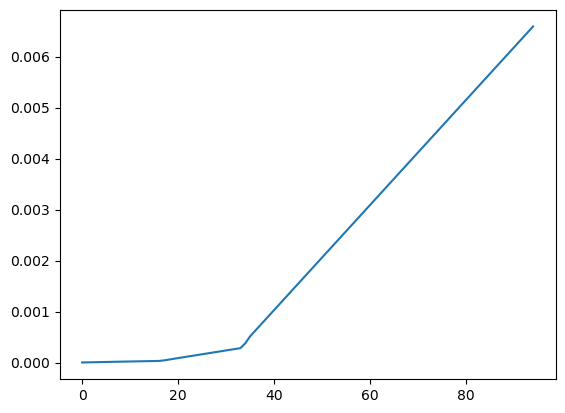

In [27]:
plt.plot(diameter)

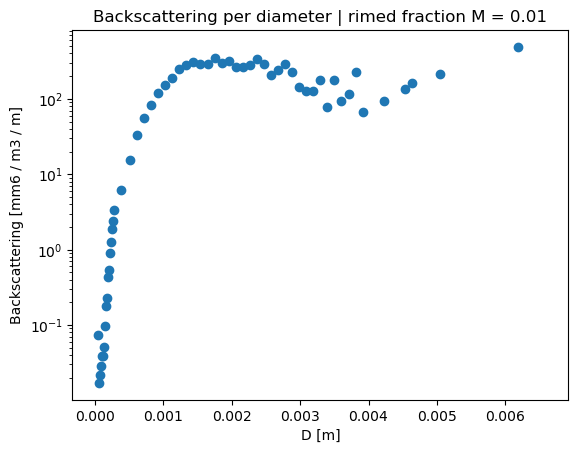

In [28]:
plt.figure()
plt.plot(diameter, back_spec, 'o')
plt.xlabel("D [m]")
plt.ylabel("Backscattering [mm6 / m3 / m]")
plt.title(f"Backscattering per diameter | rimed fraction M = 0.01")
plt.yscale("log")

In [29]:
sigma_ref = cumulative_trapezoid(back_spec, x=diameter, initial=0.0)
sigma_ref

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.57940102e-07, 1.07531351e-06, 1.36525752e-06,
       1.73870647e-06, 2.24272680e-06, 2.82907472e-06, 3.50970241e-06,
       4.63099696e-06, 6.69921730e-06, 9.73773262e-06, 1.46690387e-05,
       2.19229279e-05, 3.27052924e-05, 4.89081788e-05, 7.24283468e-05,
       1.04464979e-04, 1.47725437e-04, 5.96175152e-04, 2.06056581e-03,
       4.54532663e-03, 9.07970406e-03, 1.61851684e-02, 2.67013515e-02,
       4.08479315e-02, 5.85737316e-02, 8.11725179e-02, 1.08656226e-01,
       1.39175659e-01, 1.69819791e-01, 1.99778406e-01, 2.32979880e-01,
       2.66268226e-01, 2.97742228e-01, 3.27780760e-01, 3.55034187e-01,
       3.82955052e-01, 4.14738573e-01, 4.47186094e-01, 4.73025645e-01,
      

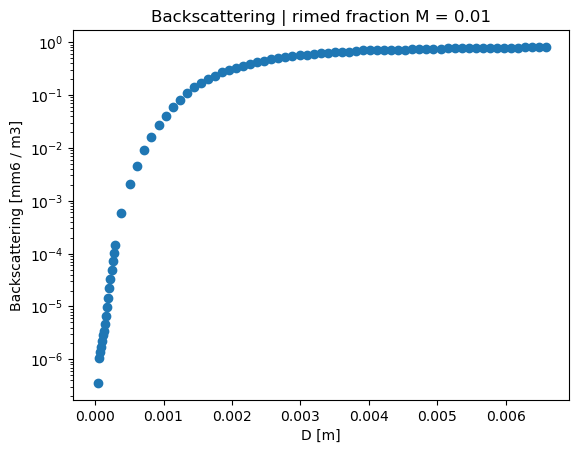

In [30]:
plt.figure()
plt.plot(diameter, sigma_ref, 'o')
plt.xlabel("D [m]")
plt.ylabel("Backscattering [mm6 / m3]")
plt.title(f"Backscattering | rimed fraction M = 0.01")
plt.yscale("log")

In [31]:
M

array([0.01])

In [32]:
K2 = 0.92

freq = 24.15e9 # Hz
#freq = 24.29e9 # Hz (post 2011) TODO re-run with this! (M&K also!)
lm = 299792458. / freq

# sigma_ref = (1e18/ (K2*np.pi**5) ) * sigma_D * (lm)**4
(K2 * np.pi**5) / (1e18 * (lm)**4)

1.1855583112515325e-08

In [33]:
sigma_D = ( (K2 * np.pi**5) / (1e18 * (lm)**4) ) * sigma_ref  # backscattering cross section per volume in m2/m3
sigma_D

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 4.24358862e-15, 1.27484687e-14, 1.61859240e-14,
       2.06133790e-14, 2.65888340e-14, 3.35403305e-14, 4.16095686e-14,
       5.49031694e-14, 7.94231275e-14, 1.15446498e-13, 1.73910007e-13,
       2.59909094e-13, 3.87740313e-13, 5.79834979e-13, 8.58680285e-13,
       1.23849324e-12, 1.75137119e-12, 7.06800407e-12, 2.44292092e-11,
       5.38874976e-11, 1.07645186e-10, 1.91884609e-10, 3.16560092e-10,
       4.84276047e-10, 6.94425743e-10, 9.62347532e-10, 1.28818292e-09,
       1.65000859e-09, 2.01331265e-09, 2.36848949e-09, 2.76211233e-09,
       3.15676508e-09, 3.52990774e-09, 3.88603204e-09, 4.20913731e-09,
       4.54015545e-09, 4.91696763e-09, 5.30165190e-09, 5.60799485e-09,
      

In [34]:
pyPamtra.descriptorFile.ssrga_parameter(M)[4]

array([0.59393885])

In [35]:
ea = 1/pyPamtra.descriptorFile.ssrga_parameter(M)[4]

In [36]:
Dmax_mm = diameter * 1e3 * ea

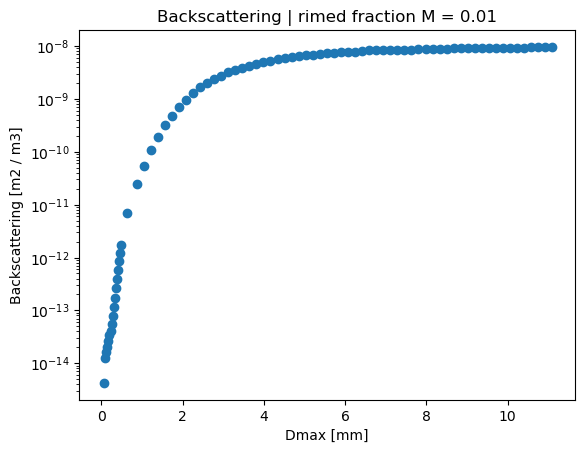

In [37]:
plt.figure()
plt.plot(Dmax_mm, sigma_D, 'o')
plt.xlabel("Dmax [mm]")
plt.ylabel("Backscattering [m2 / m3]")
plt.title(f"Backscattering | rimed fraction M = 0.01")
plt.yscale("log")

In [38]:
diameter.shape

(300,)

In [39]:
1e0

1.0

In [40]:
np.pi

3.141592653589793

In [41]:
sigma_D.shape

(300,)

### Iterate for M
Compute and plot backscattering cross section (sigma_b) at 24 GHz
for an array of particle diameters (mm) and rimed fractions M
using pyPamtra SSRGA standard ensemble.

In [42]:
# ---------------------- USER INPUT ----------------------
diameters_mm = np.linspace(0.05, 25, round(25/0.05))   # diameters in mm
M_list = (10**np.linspace(-2, 0, 11)).round(2)         # rimed fraction 0..1
# --------------------------------------------------------

# Prepare 2D array to store sigma_b and Dmax_mm
sigma_b_array = np.zeros((len(diameters_mm), len(M_list)))
Dmax_mm_array = np.zeros((len(diameters_mm), len(M_list)))


In [43]:
# Iterate over M
for i, Mint in enumerate(M_list):
    M = np.full(1, Mint)
    
    pam.df.addFullSpectra()

    ## Configure SSRGA
    pam.df.dataFullSpec["d_bound_ds"][:] = Dbound
    pam.df.dataFullSpec["d_ds"][:] = Dmean
    pam.df.dataFullSpec["n_ds"][0,0,:,0,:] = (psd_l) * np.diff(Dbound)  
    pam.df.dataFullSpec['n_ds'][0,0,:,1,:] = (psd_i) * np.diff(Dbound)
    
    # liquid droplets
    pam.df.dataFullSpec["rho_ds"][0,0,:,0,:] = 1000.
    pam.df.dataFullSpec["area_ds"][0,0,:,0,:] = (np.pi / 4. * pam.df.dataFullSpec["d_ds"][0,0,:,0,:]**2)
    pam.df.dataFullSpec["mass_ds"][0,0,:,0,:] = (np.pi / 6. * pam.df.dataFullSpec["rho_ds"][0,0,:,0,:] * 
                                                 pam.df.dataFullSpec["d_ds"][0,0,:,0,:]**3)
    pam.df.dataFullSpec["as_ratio"][0,0,:,0,:] = 1.0
    
    # rimed ice particles
    a_m = np.expand_dims(pyPamtra.descriptorFile.riming_dependent_mass_size(M, 'dendrite')[0], 1) # mass size prefactor
    b_m = np.expand_dims(pyPamtra.descriptorFile.riming_dependent_mass_size(M, 'dendrite')[1], 1) # mass size exponent
    a_a = np.expand_dims(pyPamtra.descriptorFile.riming_dependent_area_size(M, 'dendrite')[0], 1) # area size prefactor 
    b_a = np.expand_dims(pyPamtra.descriptorFile.riming_dependent_area_size(M, 'dendrite')[1], 1) # area size exponent 
    
    pam.df.dataFullSpec["area_ds"][0,0,:,1,:] = (a_a * pam.df.dataFullSpec["d_ds"][0,0,:,1,:]**b_a)
    pam.df.dataFullSpec["mass_ds"][0,0,:,1,:] = (a_m * pam.df.dataFullSpec["d_ds"][0,0,:,1,:]**b_m)
    
    pam.df.dataFullSpec["as_ratio"][0,0,:,1,:]    = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[4], 1) # alpha_eff
    pam.df.dataFullSpec["rg_kappa_ds"][0,0,:,1,:] = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[0], 1) 
    pam.df.dataFullSpec["rg_beta_ds"][0,0,:,1,:]  = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[1], 1) 
    pam.df.dataFullSpec["rg_gamma_ds"][0,0,:,1,:] = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[2], 1) 
    pam.df.dataFullSpec["rg_zeta_ds"][0,0,:,1,:]  = np.expand_dims(pyPamtra.descriptorFile.ssrga_parameter(M)[3], 1)

    pam.runPamtra(frequencies)
    if pam.fortError != 0:
        warning('Fortran errors!')


    diameter = pam.fortObject.vars_output.out_debug_diameter  # [m]
    diameter = np.where(diameter == 0, np.nan, diameter)
    
    back_spec = pam.fortObject.vars_output.out_debug_back_of_d            # [mm6/m³/m]
    sigma_ref = cumulative_trapezoid(back_spec, x=diameter, initial=0.0)  # [mm6/m³]
    sigma_ref
    
    # sigma_ref = np.where(sigma_ref == 0, np.nan, sigma_ref)
    
    Dmax_mm_variable  = diameter/pyPamtra.descriptorFile.ssrga_parameter(M)[4] * 1e3    # [mm]
    sigma_ref_uniform = np.interp(diameters_mm, Dmax_mm_variable, sigma_ref)

    sigma_b = sigma_ref_uniform * K2 * (np.pi)**5 * 1e-18 * (lm)**-4         # [m2/m3]

    sigma_b_array[:,i] = sigma_b


In [44]:
diameters_mm

array([ 0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,  0.4 ,  0.45,
        0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,  0.8 ,  0.85,  0.9 ,
        0.95,  1.  ,  1.05,  1.1 ,  1.15,  1.2 ,  1.25,  1.3 ,  1.35,
        1.4 ,  1.45,  1.5 ,  1.55,  1.6 ,  1.65,  1.7 ,  1.75,  1.8 ,
        1.85,  1.9 ,  1.95,  2.  ,  2.05,  2.1 ,  2.15,  2.2 ,  2.25,
        2.3 ,  2.35,  2.4 ,  2.45,  2.5 ,  2.55,  2.6 ,  2.65,  2.7 ,
        2.75,  2.8 ,  2.85,  2.9 ,  2.95,  3.  ,  3.05,  3.1 ,  3.15,
        3.2 ,  3.25,  3.3 ,  3.35,  3.4 ,  3.45,  3.5 ,  3.55,  3.6 ,
        3.65,  3.7 ,  3.75,  3.8 ,  3.85,  3.9 ,  3.95,  4.  ,  4.05,
        4.1 ,  4.15,  4.2 ,  4.25,  4.3 ,  4.35,  4.4 ,  4.45,  4.5 ,
        4.55,  4.6 ,  4.65,  4.7 ,  4.75,  4.8 ,  4.85,  4.9 ,  4.95,
        5.  ,  5.05,  5.1 ,  5.15,  5.2 ,  5.25,  5.3 ,  5.35,  5.4 ,
        5.45,  5.5 ,  5.55,  5.6 ,  5.65,  5.7 ,  5.75,  5.8 ,  5.85,
        5.9 ,  5.95,  6.  ,  6.05,  6.1 ,  6.15,  6.2 ,  6.25,  6.3 ,
        6.35,  6.4 ,

In [45]:
Dmax_mm_variable

array([4.46670970e-03, 7.10092312e-03, 1.01359951e-02, 1.24838810e-02,
       1.44881738e-02, 1.69505907e-02, 1.90694145e-02, 2.06155833e-02,
       2.25626106e-02, 2.49677619e-02, 2.72011168e-02, 2.90908786e-02,
       3.08088439e-02, 3.28131367e-02, 3.51037570e-02, 3.72798464e-02,
       3.91123427e-02, 5.03936479e-02, 6.87186108e-02, 8.58982635e-02,
       1.03077916e-01, 1.20257569e-01, 1.37437222e-01, 1.54616874e-01,
       1.71796527e-01, 1.88976180e-01, 2.06155833e-01, 2.23335485e-01,
       2.40515138e-01, 2.57694791e-01, 2.74874443e-01, 2.92054096e-01,
       3.09233749e-01, 3.26413401e-01, 4.33499903e-01, 5.89834743e-01,
       7.07801692e-01, 8.25768640e-01, 9.43735589e-01, 1.06170254e+00,
       1.17966949e+00, 1.29763643e+00, 1.41560338e+00, 1.53357033e+00,
       1.65153728e+00, 1.76950423e+00, 1.88747118e+00, 2.00543813e+00,
       2.12340507e+00, 2.24137202e+00, 2.35933897e+00, 2.47730592e+00,
       2.59527287e+00, 2.71323982e+00, 2.83120677e+00, 2.94917372e+00,
      

In [46]:
# sigma_b_array = np.where(sigma_b_array == 0, np.nan, sigma_b_array)
sigma_b_array

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.27579219e-14, 4.73343977e-14, 1.97547676e-13],
       [1.24262850e-14, 6.94223042e-15, 7.15309945e-15, ...,
        1.58518307e-13, 3.64811617e-13, 1.19367917e-12],
       [2.03450241e-14, 1.20782972e-14, 1.31051056e-14, ...,
        4.26777043e-13, 1.04568015e-12, 3.35738779e-12],
       ...,
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], shape=(500, 11))

In [47]:
# Save CSV
df = pd.DataFrame(sigma_b_array, index=diameters_mm, columns=M_list)
df.to_csv("sigma_b_24ghz.csv")
print("CSV saved: sigma_b_24ghz.csv")

# # Save as NetCDF
# ds = xr.Dataset({'sigma_b': (['M','diameter_mm'], sigma_b_array)},
#                 coords={'M': M_list, 'diameter_mm': diameters_mm})
# ds.to_netcdf("sigma_b_24ghz.nc")
# print("NetCDF saved: sigma_b_24ghz.nc")

CSV saved: sigma_b_24ghz.csv


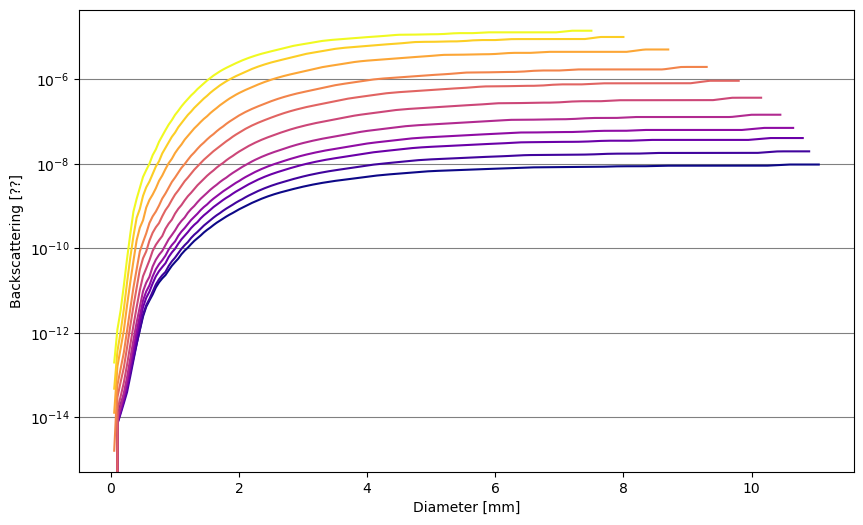

In [48]:
# --- Colormap ---
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(M_list)))  # genera colore progressivo per ogni M

# --- Plot ---
plt.figure(figsize=(10,6))

for i, M in enumerate(M_list):
    plt.plot(diameters_mm, sigma_b_array[:,i], color=colors[i], label=f'M={M:.1f}')

# plt.xlabel('Diametro D (mm)')
# plt.ylabel('Sezione d\'urto σ (m²)')
# plt.title('σ di ghiaccio rimato vs D (linee colorate per M)')
# plt.grid(True)

plt.xlabel("Diameter [mm]")
plt.ylabel("Backscattering [??]")
plt.yscale("log")

plt.grid(axis='y', color='gray', which='major')
plt.grid(axis='y', color='gray', which='minor', alpha=0.5)

# plt.tight_layout()

plt.show()

In [49]:
M_list

array([0.01, 0.02, 0.03, 0.04, 0.06, 0.1 , 0.16, 0.25, 0.4 , 0.63, 1.  ])